In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

####  Read the data

In [2]:
udf = pd.read_csv('Universities.csv', index_col='Univ')
udf.head()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
Univ,,,,,,
Brown,1310,89,22,13,22704,94
CalTech,1415,100,25,6,63575,81
CMU,1260,62,59,9,25026,72
Columbia,1310,76,24,12,31510,88
Cornell,1280,83,33,13,21864,90


#### Standardize the data -<font color='red'> Mandatory step </font>

In [3]:
from sklearn.preprocessing import StandardScaler

In [4]:
scaler = StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(udf), columns=udf.columns, index=udf.index)
scaled_df.head()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
Univ,,,,,,
Brown,0.410284,0.657519,-0.889867,0.070260,-0.331413,0.820303
CalTech,1.399259,1.235212,-0.734657,-1.686251,2.560381,-0.644524
CMU,-0.060657,-0.760454,1.024382,-0.933460,-0.167121,-1.658634
Columbia,0.410284,-0.025208,-0.786394,-0.180670,0.291649,0.144229
Cornell,0.127719,0.342414,-0.320766,0.070260,-0.390846,0.369587


#### Build PCA Model

In [5]:
from sklearn.decomposition import PCA

In [6]:
model = PCA(n_components=6)
pcomp_df = pd.DataFrame(model.fit_transform(scaled_df), columns=[ 'PC1','PC2','PC3','PC4','PC5','PC6'], index=udf.index)
pcomp_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6
Univ,,,,,,
Brown,1.009874,-1.064310,0.081066,-0.056951,-0.128754,-0.034650
CalTech,2.822238,2.259045,0.836829,-0.143845,-0.125962,-0.180703
CMU,-1.112466,1.631209,-0.266787,-1.075075,-0.191814,0.345679
Columbia,0.741741,-0.042187,0.060501,0.157208,-0.577611,0.109163
Cornell,0.311912,-0.635244,0.010241,-0.171364,0.012726,-0.016921


In [7]:
var = model.explained_variance_ratio_
var

array([0.76868084, 0.13113602, 0.04776031, 0.02729668, 0.0207177 ,
       0.00440844])

In [8]:
np.cumsum(var)

array([0.76868084, 0.89981687, 0.94757718, 0.97487386, 0.99559156,
       1.        ])

In [9]:
final_dataset = pcomp_df[['PC1','PC2','PC3']]
final_dataset.head()

,PC1,PC2,PC3
Univ,,,
Brown,1.009874,-1.064310,0.081066
CalTech,2.822238,2.259045,0.836829
CMU,-1.112466,1.631209,-0.266787
Columbia,0.741741,-0.042187,0.060501
Cornell,0.311912,-0.635244,0.010241


>Note: Reduced dimensionality from 6 features to 3 features, retaining 95% of information

#### TSNE
For visualization

In [10]:
iris = pd.read_csv('iris.csv')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [11]:
data = iris.copy()

In [12]:
from sklearn.manifold import TSNE

In [13]:
tmodel = TSNE(n_components=2)
tcomp_df = pd.DataFrame(tmodel.fit_transform(data.drop('species', axis=1)), columns=['TC1','TC2'])
tcomp_df['species'] = data['species']
tcomp_df.head()

,TC1,TC2,species
0,-25.502390,-1.643927,setosa
1,-23.042055,-0.994582,setosa
2,-22.787239,-2.096912,setosa
3,-22.498199,-1.861895,setosa
4,-25.574633,-2.148222,setosa


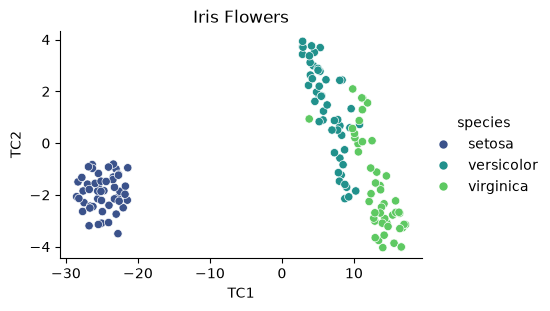

In [14]:
sns.relplot(tcomp_df, x='TC1', y='TC2',
            kind='scatter',
            hue='species',
            palette='viridis',
            height=3,
            aspect=1.5
           )
plt.title('Iris Flowers')
plt.show()